<a href="https://colab.research.google.com/github/danabelgibek/Bagyt/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PIP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
import requests
import re
import time
import random

# Parsing

# my own variant


In [ ]:
from bs4 import BeautifulSoup
import requests
import re
import sys
sys.stdout.reconfigure(encoding='utf-8')

url  = 'https://krisha.kz/prodazha/kvartiry/shymkent/?das[house.year][to]=2022&das[who]=1'
result = requests.get(url).text
doc = BeautifulSoup(result,'html.parser')
header = doc.find_all('a',class_='a-card__title')
def finding_title(header):
     for  title in header:
         print(title.get_text(strip = True))
prices= doc.find_all('div',class_= 'a-card__price')
for i in prices:
    print(i.get_text(strip = True))
place = doc.find_all('div',class_='a-card__subtitle')
for i in place:
     text = i.get_text(strip =True)
     first_word = text.split()[0]
     print(first_word)
y = doc.find_all('div',class_ = 'a-card__text-preview')
for i in year:
     clear = i.get_text(strip = True)
    #print(clear)
year = doc.find_all('li', class_='a-parameter')
for li in year:
     name = li.find('div', class_='a-parameter__name')
     value = li.find('div', class_='a-parameter__value')
     if name and 'Год постройки' in name.get_text(strip=True):
         print(value.get_text(strip=True))
params = doc.find_all('li', class_='a-parameter')

for li in params:
     name_tag = li.find('div', class_='a-parameter__name')
     value_tag = li.find('div', class_='a-parameter__value')

     if name_tag and 'Год постройки' in name_tag.get_text(strip=True):
         year = value_tag.get_text(strip=True)
         print(year)
titles = doc.find_all('a', class_='a-card__title')
prices = doc.find_all('div', class_='a-card__price')
previews = doc.find_all('div', class_='a-card__text-preview')

for t, p, pr in zip(titles, prices, previews):
     title = t.get_text(strip=True)
     price = p.get_text(strip=True).replace('\xa0', ' ')
     text = pr.get_text(strip=True)

     year_match = re.search(r'(\d{4})\s*г\.?\s*п\.?', text)
     year = year_match.group(1) if year_match else '—'

     print(title, price, year)
print(doc.prettify)

# advanced parser

In [ ]:
BASE_URL = 'https://krisha.kz/prodazha/kvartiry/almaty/?das[house.year][to]=2024&das[who]=1'

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

TARGET_ROWS = 11900
MAX_PAGES   = 1000

flats = []

In [ ]:
def parse_page(html):
    """
    Парсит одну HTML-страницу Krisha и возвращает список словарей с инфой по квартирам.
    """
    doc = BeautifulSoup(html, 'html.parser')

    titles   = doc.find_all('a',   class_='a-card__title')
    prices   = doc.find_all('div', class_='a-card__price')
    places   = doc.find_all('div', class_='a-card__subtitle')
    previews = doc.find_all('div', class_='a-card__text-preview')

    page_flats = []

    for t, p, pl, pr in zip(titles, prices, places, previews):
        # ---- basic fields ----
        title = t.get_text(strip=True)

        price_raw = p.get_text(strip=True)
        # remove non-breaking spaces and extra spaces
        price = re.sub(r'\s+', ' ', price_raw.replace('\xa0', ' '))

        place_full = pl.get_text(strip=True)  # full address/region
        # main_place — first element in column (by comma or space)
        if ',' in place_full:
            main_place = place_full.split(',')[0]
        else:
            main_place = place_full.split()[0] if place_full.split() else None

        preview_text = pr.get_text(strip=True)

        # To extract characteristics, we use the combined text:
        all_text = f"{title} {preview_text}"

        # ---- Year of construction ----
        year_match = re.search(r'(\d{4})\s*г\.?\s*п?\.?', all_text)
        year = int(year_match.group(1)) if year_match else None

        # ---- Number of rooms ----
        rooms_match = re.search(r'(\d+)\s*[-\s]*к(омн|омнат|\.?)', all_text, re.IGNORECASE)
        rooms = int(rooms_match.group(1)) if rooms_match else None

        # ---- Area (м²) ----
        area_match = re.search(r'(\d+(?:\.\d+)?)\s*(?:м²|м2|кв\.?\s*м)', all_text)
        area_m2 = float(area_match.group(1)) if area_match else None

        # ---- floor / total floor ----
        floor = None
        total_floors = None

        #options like "5/9 floor" or "5/9 fl."
        floor_match = re.search(r'(\d+)\s*/\s*(\d+)\s*этаж', all_text, re.IGNORECASE)
        if not floor_match:
            floor_match = re.search(r'(\d+)\s*/\s*(\d+)\s*эт', all_text, re.IGNORECASE)

        # option like "5th floor out of 9""
        if not floor_match:
            floor_match = re.search(r'(\d+)\s*этаж\s*из\s*(\d+)', all_text, re.IGNORECASE)

        if floor_match:
            floor = int(floor_match.group(1))
            total_floors = int(floor_match.group(2))

        flat_info = {
            "title":        title,
            "price":        price,
            "place":        place_full,
            "main_place":   main_place,
            "year":         year,
            "rooms":        rooms,
            "area_m2":      area_m2,
            "floor":        floor,
            "total_floors": total_floors,
        }

        page_flats.append(flat_info)

    return page_flats


In [ ]:
def make_url(page_num: int) -> str:
    """Returns the URL for the specified page."""
    if page_num == 1:
        return BASE_URL
    else:
        return BASE_URL + f"&page={page_num}"


In [ ]:

print("Starting parsing...")

Starting parsing...


In [ ]:
page = 1
while len(flats) < TARGET_ROWS and page <= MAX_PAGES:
    url = make_url(page)
    print(f"\nParsing the page {page}: {url}")

    resp = requests.get(url, headers=HEADERS)
    if resp.status_code != 200:
        print(f"Page {page} returned the status {resp.status_code}. Stopping.")
        break

    page_flats = parse_page(resp.text)

    if not page_flats:
        print("No ads found on this page. Stopping.")
        break

    flats.extend(page_flats)
    print(f"Total number of ads collected: {len(flats)}")

    page += 1
    # Небольшая пауза, чтобы не спамить сайт
    time.sleep(random.uniform(1, 3))

# обрежем до нужного количества строк, если собрали больше
flats = flats[:TARGET_ROWS]
print(f"\nTotal number of ads collected: {len(flats)}")


Parsing the page 1: https://krisha.kz/prodazha/kvartiry/almaty/?das[house.year][to]=2024&das[who]=1
Total number of ads collected: 20

Parsing the page 2: https://krisha.kz/prodazha/kvartiry/almaty/?das[house.year][to]=2024&das[who]=1&page=2
Total number of ads collected: 40

Parsing the page 3: https://krisha.kz/prodazha/kvartiry/almaty/?das[house.year][to]=2024&das[who]=1&page=3
Total number of ads collected: 60

Parsing the page 4: https://krisha.kz/prodazha/kvartiry/almaty/?das[house.year][to]=2024&das[who]=1&page=4
Total number of ads collected: 80

Parsing the page 5: https://krisha.kz/prodazha/kvartiry/almaty/?das[house.year][to]=2024&das[who]=1&page=5
Total number of ads collected: 100

Parsing the page 6: https://krisha.kz/prodazha/kvartiry/almaty/?das[house.year][to]=2024&das[who]=1&page=6
Total number of ads collected: 120

Parsing the page 7: https://krisha.kz/prodazha/kvartiry/almaty/?das[house.year][to]=2024&das[who]=1&page=7
Total number of ads collected: 140

Parsing t

In [ ]:
# ===== Save as CSV to the current folder (Google Colab: /content)=====
df = pd.DataFrame(flats)

csv_path = "krisha_almaty_flats.csv"  # обычное расширение .csv
df.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f"Data saved to file: {csv_path}")


# Let's look at the first lines
df.head()

Data saved to file: krisha_almaty_flats.csv


,title,price,place,main_place,year,rooms,area_m2,floor,total_floors
0,4-комнатная квартира · 182.7 м²,от 228 375 000〒,"Бостандыкский р-н, Мусабаева 15",Бостандыкский р-н,2023,4,182.7,NaN,NaN
1,3-комнатная квартира · 94 м² · 2/10 этаж,49 000 000〒,"Наурызбайский р-н, мкр Шугыла 340/36 к 2",Наурызбайский р-н,2023,3,94.0,2.0,10.0
2,3-комнатная квартира · 70 м² · 1/5 этаж,58 000 000〒,"Ауэзовский р-н, мкр Таугуль 13 — Саина Жандосова",Ауэзовский р-н,1993,3,70.0,1.0,5.0
3,4-комнатная квартира · 172 м² · 3/4 этаж,242 000 000〒,"Бостандыкский р-н, Мирас 53–64",Бостандыкский р-н,2006,4,172.0,3.0,4.0
4,2-комнатная квартира · 56 м² · 8/10 этаж,38 500 000〒,"Наурызбайский р-н, мкр Каргалы, Кенесары хана ...",Наурызбайский р-н,2012,2,56.0,8.0,10.0


#data understanding


In [ ]:
df = pd.read_csv('krisha_almaty_flats.csv')
df.head()

,title,price,place,main_place,year,rooms,area_m2,floor,total_floors
0,2-комнатная квартира · 60 м² · 1/4 этаж,37 000 000〒,"Бостандыкский р-н, мкр Орбита-3, Торайгырова —...",Бостандыкский р-н,1975,2,60.0,1.0,4.0
1,2-комнатная квартира · 65 м² · 1/4 этаж,63 000 000〒,"Медеуский р-н, мкр Юбилейный, Омаровой",Медеуский р-н,2019,2,65.0,1.0,4.0
2,1-комнатная квартира · 19.5 м² · 3/3 этаж,10 500 000〒,"Турксибский р-н, Ганибет 27б — По Ленинской смене",Турксибский р-н,1973,1,19.5,3.0,3.0
3,3-комнатная квартира · 126 м² · 1/5 этаж,90 000 000〒,"Медеуский р-н, проспект Достык 111/4 — Выше ул...",Медеуский р-н,1985,3,126.0,1.0,5.0
4,2-комнатная квартира · 70 м² · 1/3 этаж,52 500 000〒,"Бостандыкский р-н, мкр Нурлытау (Энергетик), М...",Бостандыкский р-н,2024,2,70.0,1.0,3.0


In [ ]:
df.sample(5)

,title,price,place,main_place,year,rooms,area_m2,floor,total_floors
5255,2-комнатная квартира · 46.7 м² · 4/5 этаж,45 000 000〒,"Бостандыкский р-н, Басенова 27",Бостандыкский р-н,1977,2,46.7,4.0,5.0
6272,2-комнатная квартира · 52 м² · 2/3 этаж,48 500 000〒,"Наурызбайский р-н, мкр Курамыс, Акселеу Сейдим...",Наурызбайский р-н,2021,2,52.0,2.0,3.0
6601,2-комнатная квартира · 78 м² · 2/12 этаж,48 000 000〒,"Ауэзовский р-н, Толе би 298/7 — Толе би",Ауэзовский р-н,2013,2,78.0,2.0,12.0
7147,2-комнатная квартира · 66.1 м² · 5/9 этаж,36 500 000〒,"Турксибский р-н, мкр Жас Канат, Е.Хасангалиева...",Турксибский р-н,2016,2,66.1,5.0,9.0
4934,3-комнатная квартира · 60 м² · 5/5 этаж,34 000 000〒,"Жетысуский р-н, мкр Айнабулак-3 134 — Павлодар...",Жетысуский р-н,1988,3,60.0,5.0,5.0


In [ ]:
df.shape


(10000, 9)

In [ ]:
df.columns

Index(['title', 'price', 'place', 'main_place', 'year', 'rooms', 'area_m2',
       'floor', 'total_floors'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11900 entries, 0 to 11899
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         11900 non-null  object 
 1   price         11900 non-null  object 
 2   place         11900 non-null  object 
 3   main_place    11900 non-null  object 
 4   year          11900 non-null  int64  
 5   rooms         11900 non-null  int64  
 6   area_m2       11900 non-null  float64
 7   floor         11415 non-null  float64
 8   total_floors  11415 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 836.8+ KB


In [ ]:
df.describe()

,year,rooms,area_m2,floor,total_floors
count,11900.000000,11900.000000,11900.000000,11415.000000,11415.000000
mean,2003.549412,2.280336,67.303423,5.017346,8.405957
std,20.705771,0.989176,37.283089,3.741500,4.608226
min,1912.000000,1.000000,8.000000,1.000000,1.000000
25%,1985.000000,2.000000,44.400000,2.000000,5.000000
50%,2013.000000,2.000000,60.000000,4.000000,8.000000
75%,2022.000000,3.000000,79.340000,7.000000,12.000000
max,2024.000000,14.000000,543.000000,25.000000,33.000000


In [ ]:
df["main_place"].value_counts()

,count
main_place,
Бостандыкский р-н,2092
Ауэзовский р-н,1646
Алмалинский р-н,1286
Алатауский р-н,1231
Наурызбайский р-н,1100
...,...
20-я,1
Жуалы,1
Водник,1


# Cleaning

In [ ]:
# import pandas as pd
# import numpy as np

df = pd.read_csv('krisha_almaty_flats.csv')
print(df.info())
print(df.isnull().sum())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         10000 non-null  object 
 1   price         10000 non-null  object 
 2   place         10000 non-null  object 
 3   main_place    10000 non-null  object 
 4   year          10000 non-null  int64  
 5   rooms         10000 non-null  int64  
 6   area_m2       10000 non-null  float64
 7   floor         9587 non-null   float64
 8   total_floors  9587 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 703.3+ KB
None
title             0
price             0
place             0
main_place        0
year              0
rooms             0
area_m2           0
floor           413
total_floors    413
dtype: int64
                                       title        price  \
0    2-комнатная квартира · 60 м² · 1/4 этаж  37 000 000〒   
1    2-комнатная квартира · 65 м² · 

### Converting columns to the required formats to simplify and eliminate characters

p.s.

error='coerce'

"If an error occurs while coercing data, don't stop the program; simply replace the problematic value with NaN."


In [ ]:

df["year"] = pd.to_numeric(df["year"], errors = 'coerce').astype('Int64')
df["floor"] = pd.to_numeric(df["floor"], errors = 'coerce').astype('Int64')
df["area_m2"] = pd.to_numeric(df["area_m2"], errors = 'coerce').astype('float')
df["total_floors"] = pd.to_numeric(df["total_floors"], errors = 'coerce').astype('Int64')

df["price"] = df["price"].apply(lambda x: str(x).replace('\xa0', ' ').replace(' ', '').replace('〒','').replace('от', ''))
df["price"] = pd.to_numeric(df["price"], errors = 'coerce').astype('Int64')

print(f"Getting rid of tenge symbols and spaces...")
print(f"Converting columns to int and float...")

Getting rid of tenge symbols and spaces...
Converting columns to int and float...


Removing duplicates and giving a new numerical index

In [ ]:
df = df.drop(columns=['title','place'])
before = len(df)
df = df.drop_duplicates()
after = len(df)



df = df.reset_index(drop=True)
print(f"Removed: {before - after} duplicates")
print(f"Reset the current df index, replacing it with a new numeric index")

Removed: 279 duplicates
Reset the current df index, replacing it with a new numeric index


Checking for unique values ​​and parser errors

In [ ]:
unique_year = df['year'].unique()
unique_floor = df['floor'].unique()
unique_area = df['area_m2'].unique()
unique_tf = df['total_floors'].unique()

print(f"Checking unique values ​​in columns: \n{df.nunique()}\n")
print(f"Checking column year for outliers: \n{np.sort(unique_year)[::-1]}\n") #sort ascending
print(f"Checking column floor for outliers: \n{np.sort(unique_floor)}\n")
print(f"Checking column total_floors for outliers: \n{np.sort(unique_tf)}\n")
print(f"Checking column total_floors for outliers: \n{np.sort(unique_area)}\n")
print(f"Checking parser errors: \n{df['main_place'].unique()}\n")



Checking unique values ​​in columns: 
price            959
main_place       138
year              86
rooms             12
area_m2         1131
floor             25
total_floors      30
dtype: int64

Checking column year for outliers: 
[2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011
 2010 2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997
 1996 1995 1994 1993 1992 1991 1990 1989 1988 1987 1986 1985 1984 1983
 1982 1981 1980 1979 1978 1977 1976 1975 1974 1973 1972 1971 1970 1969
 1968 1967 1966 1965 1964 1963 1962 1961 1960 1959 1958 1957 1956 1955
 1954 1953 1952 1951 1950 1949 1948 1947 1946 1943 1940 1939 1936 1930
 1921 1912]

Checking column floor for outliers: 
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. nan]

Checking column total_floors for outliers: 
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 25. 29. 30. 31. 32. 33. 99. nan]

Checking 

Cleaning up unusable data (trash)

In [ ]:
#This is impossible data
df.loc[df['total_floors'] == 99, 'total_floors'] = np.nan
#We're deleting data for apartments with an area larger than 300 m2, as such apartments are penthouses or footprints
df['area_m2'] = df['area_m2'].apply(lambda x: np.nan if (x > 300) else x)
df = df[df["area_m2"].notna() & (df["area_m2"] > 0)]
df.loc[df['floor'] > df['total_floors'], ['floor', 'total_floors']] = np.nan
df['main_place'] = df['main_place'].apply(lambda x: x if isinstance(x, str) and len(x) > 4 else np.nan)
df = df[~(df["floor"].isna() & df["total_floors"].isna())]


Final check

In [ ]:
unique_year = df['year'].unique()
unique_floor = df['floor'].unique()
unique_area = df['area_m2'].unique()
unique_tf = df['total_floors'].unique()

print(f"Checking unique values ​​in columns: \n{df.nunique()}\n")
print(f"Checking column year for outliers: \n{np.sort(unique_year)[::-1]}\n") #sort ascending
print(f"Checking column floor for outliers: \n{np.sort(unique_floor)}\n")
print(f"Checking column total_floors for outliers: \n{np.sort(unique_tf)}\n")
print(f"Checking column area_m2 for outliers: \n{np.sort(unique_area)}\n")
print(f"Checking parser errors: \n{df['main_place'].unique()}\n")

Checking unique values ​​in columns: 
price            950
main_place       121
year              86
rooms              9
area_m2         1110
floor             25
total_floors      29
dtype: int64

Checking column year for outliers: 
[2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011
 2010 2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997
 1996 1995 1994 1993 1992 1991 1990 1989 1988 1987 1986 1985 1984 1983
 1982 1981 1980 1979 1978 1977 1976 1975 1974 1973 1972 1971 1970 1969
 1968 1967 1966 1965 1964 1963 1962 1961 1960 1959 1958 1957 1956 1955
 1954 1953 1952 1951 1950 1949 1948 1947 1946 1943 1940 1939 1936 1930
 1921 1912]

Checking column floor for outliers: 
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. nan]

Checking column total_floors for outliers: 
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 25. 29. 30. 31. 32. 33. nan]

Checking colu

Saving data after cleaning

In [ ]:
df.to_csv('krisha_almary_flats_updated.csv', index = False)
print(df.info())
print(df.isnull().sum())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 11429 entries, 0 to 11454
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         11429 non-null  Int64  
 1   main_place    11404 non-null  object 
 2   year          11429 non-null  Int64  
 3   rooms         11429 non-null  int64  
 4   area_m2       11429 non-null  float64
 5   floor         10964 non-null  Int64  
 6   total_floors  10964 non-null  Int64  
dtypes: Int64(4), float64(1), int64(1), object(1)
memory usage: 759.0+ KB
None
price             0
main_place       25
year              0
rooms             0
area_m2           0
floor           465
total_floors    465
dtype: int64
       price         main_place  year  rooms  area_m2  floor  total_floors
0  228375000  Бостандыкский р-н  2023      4    182.7   <NA>          <NA>
1   49000000  Наурызбайский р-н  2023      3     94.0      2            10
2   58000000     Ауэзовский р-н  1993      3     70.0

# analyzing


## what is median price in almaty ?

In [ ]:
df = pd.read_csv('/content/krisha_almary_flats_updated (1).csv')
df.tail()

,price,main_place,year,rooms,area_m2,floor,total_floors
11424,57700000,Ауэзовский р-н,2011,2,67.0,10.0,11.0
11425,65000000,Бостандыкский р-н,2011,3,105.0,4.0,16.0
11426,85000000,Бостандыкский р-н,2022,3,73.0,2.0,3.0
11427,95000000,Медеуский р-н,2024,3,95.5,6.0,6.0
11428,55000000,Бостандыкский р-н,1991,3,79.4,5.0,5.0


general median and mean price in almaty

In [ ]:
df['price'].median()

43000000.0

In [ ]:
df['price'].mean()

np.float64(54847834.39854755)

average prices for 1,2,3 room flats

In [ ]:
avg_price_1 = df[df["rooms"] == 1]["price"].median()
print(f"Average price of 1-room apartments: {avg_price_1} tenge")

Average price of 1-room apartments: 26000000.0 tenge


In [ ]:
avg_price_2 = df[df["rooms"] == 2]["price"].median()
print(f"Average price of 2-room apartments: {avg_price_2} tenge")

Average price of 2-room apartments: 40000000.0 tenge


In [ ]:
avg_price_3 = df[df["rooms"] == 3]["price"].median()
print(f"Average price of 3-room apartments: {avg_price_3} tenge")

Average price of 3-room apartments: 55000000.0 tenge


top most expensive median prices for districts in almaty

In [ ]:
mean_by_place = df.groupby("main_place")["price"].median().sort_values(ascending=False)
top5_expensive = mean_by_place.head(5)
display(top5_expensive)

,price
main_place,
Медеуский,275000000.0
Аль фараби 9,180000000.0
Каменное,167000000.0
Аль-Фараби,132000000.0
Алатуская,108093805.0


top median price for 1 room flats

In [ ]:

one_room_flats = df[df["rooms"] == 1]


median_price_1room_by_district = (
    one_room_flats
    .groupby("main_place")["price"]
    .median()
    .sort_values(ascending=False)
)

top5_expensive_1room = median_price_1room_by_district.head(4)


display(top5_expensive_1room)


,price
main_place,
Розыбакиева,65000000.0
Курмангазы,47000000.0
Сейфуллина,44900000.0
Исаева,43500000.0


median price for 1 room flats in most popular districts

In [ ]:

selected_districts = [
    "Бостандыкский р-н",
    "Ауэзовский р-н",
    "Алмалинский р-н",
    "Алатауский р-н",
    "Наурызбайский р-н"
]


one_room_flats = df[df["rooms"] == 1]


one_room_selected = one_room_flats[
    one_room_flats["main_place"].isin(selected_districts)
]


median_price_1room_by_district = (
    one_room_selected
    .groupby("main_place")["price"]
    .median()
    .sort_values(ascending=False)
)


display(median_price_1room_by_district)


,price
main_place,
Бостандыкский р-н,33000000.0
Алмалинский р-н,31500000.0
Ауэзовский р-н,26800000.0
Алатауский р-н,25000000.0
Наурызбайский р-н,25000000.0


# price for per metr in most popular districts

In [ ]:
target_districts = [
    "Бостандыкский р-н",
    "Ауэзовский р-н",
    "Алмалинский р-н",
    "Алатауский р-н",
    "Наурызбайский р-н"
]





In [ ]:
df_filtered = df[
    (df["main_place"].isin(target_districts)) &
    (df["price"] > 0) &
    (df["area_m2"] > 0)
].copy()

df_filtered["price_per_m2"] = df_filtered["price"] / df_filtered["area_m2"]


In [ ]:
median_price_per_m2 = (
    df_filtered
    .groupby("main_place")["price_per_m2"]
    .median()
    .sort_values(ascending=False)
)

display(median_price_per_m2)


,price_per_m2
main_place,
Бостандыкский р-н,928000.000000
Алмалинский р-н,846153.846154
Ауэзовский р-н,735294.117647
Наурызбайский р-н,639116.575592
Алатауский р-н,607594.936709


# how old is our houses

In [ ]:
df['year'].describe()

,year
count,11429.000000
mean,2003.510631
std,20.722900
min,1912.000000
25%,1985.000000
50%,2013.000000
75%,2021.000000
max,2024.000000


In [ ]:
most_expensive_flat = df.loc[df['price'].idxmax()]
display(most_expensive_flat)

,8650
price,800000000
main_place,Бостандыкский р-н
year,2020
rooms,4
area_m2,300.0
floor,1.0
total_floors,3.0


# Visualization


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="muted",
    font="DejaVu Sans",
    font_scale=1.15,
    rc={
        "axes.facecolor": "#f7f9fb",
        "figure.facecolor": "#ffffff",
        "axes.edgecolor": "#d0d7de",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": "#e1e4e8",
        "grid.linestyle": "-",
        "axes.titleweight": "bold",
        "axes.titlepad": 16,
        "legend.frameon": False,
        "lines.linewidth": 2,
    },
)


df = pd.read_csv("krisha_almary_flats_updated.csv")
df = df.copy()

# Price per square meter indicator
df["price_per_m2"] = df["price"] / df["area_m2"]
# Logarithm of price
df["log_price"] = np.log10(df["price"])


The logarithmic scale is used to reduce the influence of extremely expensive objects and make the price distribution closer to normal, and the graphs more readable.

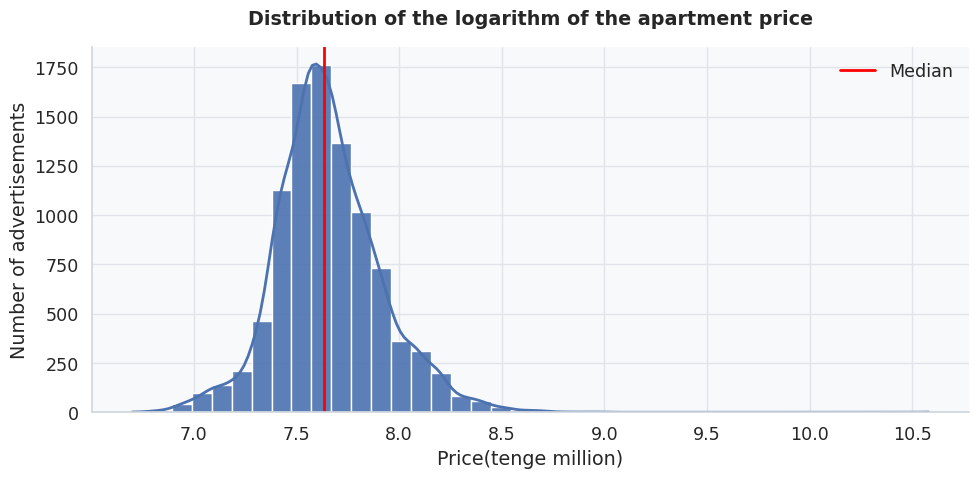

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="log_price", bins=40, kde=True,
             color="#4c72b0", edgecolor="white", alpha=0.9)
plt.axvline(df["log_price"].median(), color="red", linestyle="-", label="Median")
plt.title("Distribution of the logarithm of the apartment price")
plt.xlabel("Price(tenge million)")
plt.ylabel("Number of advertisements")
plt.legend()
plt.tight_layout()
plt.show()


CountPlot

/tmp/ipython-input-1509521525.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")


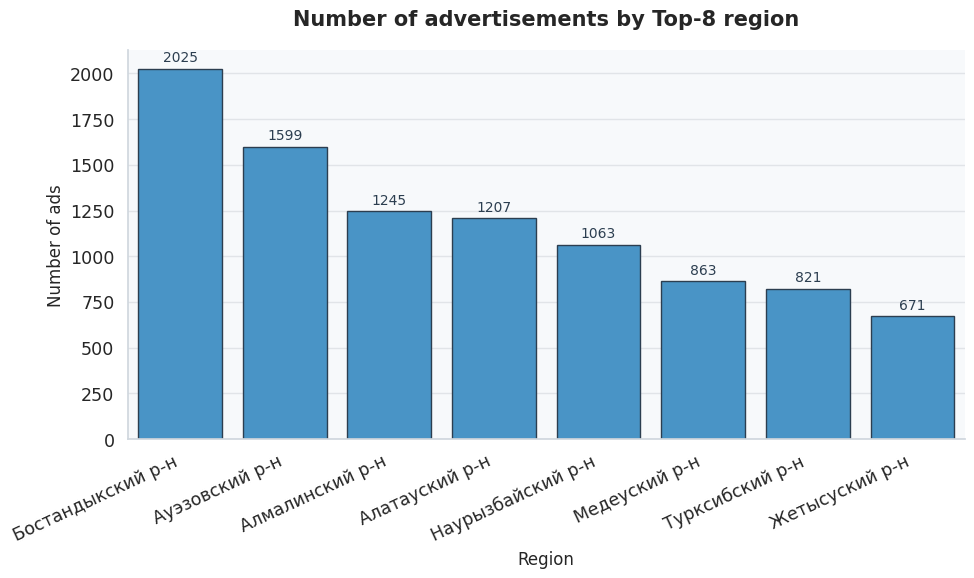

In [ ]:
top_n = 8
top_places = df["main_place"].value_counts().head(top_n).index
df_top = df[df["main_place"].isin(top_places)]

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_top,
    x="main_place",
    order=top_places,
    color="#3498db",
    edgecolor="#2c3e50"
)

ax.set_title(
    f"Number of advertisements by Top-{top_n} region",
    fontsize=15,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Number of ads", fontsize=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=10,
        color="#2c3e50"
    )

sns.despine()
plt.tight_layout()
plt.show()


BoxPlot

/tmp/ipython-input-3095976443.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


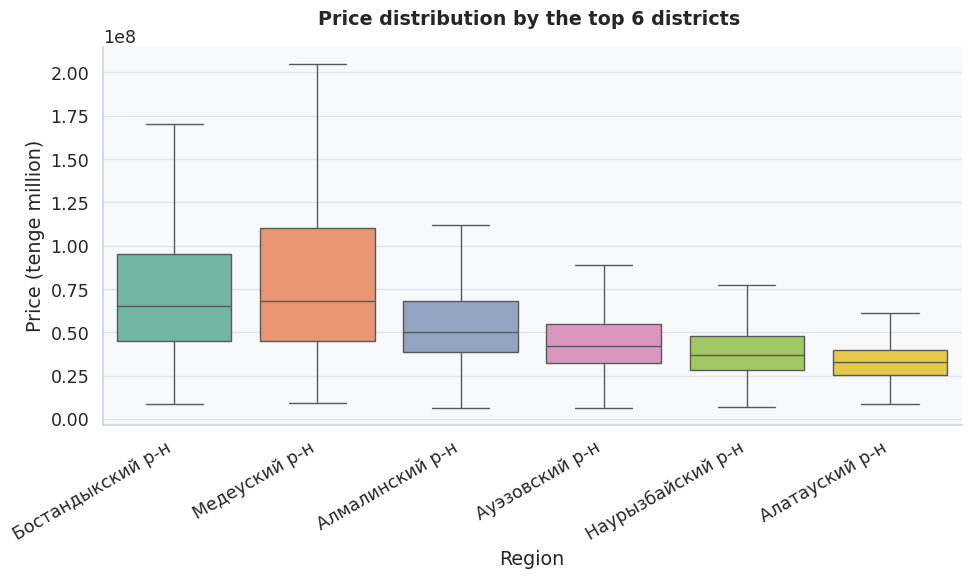

In [ ]:
top_places = df["main_place"].value_counts().head(6).index
df_top_places = df[df["main_place"].isin(top_places)]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_top_places,
    x="main_place",
    y="price",
    showfliers=False,
    palette="Set2"
)
plt.title("Price distribution by the top 6 districts ")
plt.xlabel("Region")
plt.ylabel("Price (tenge million)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Scatterplot

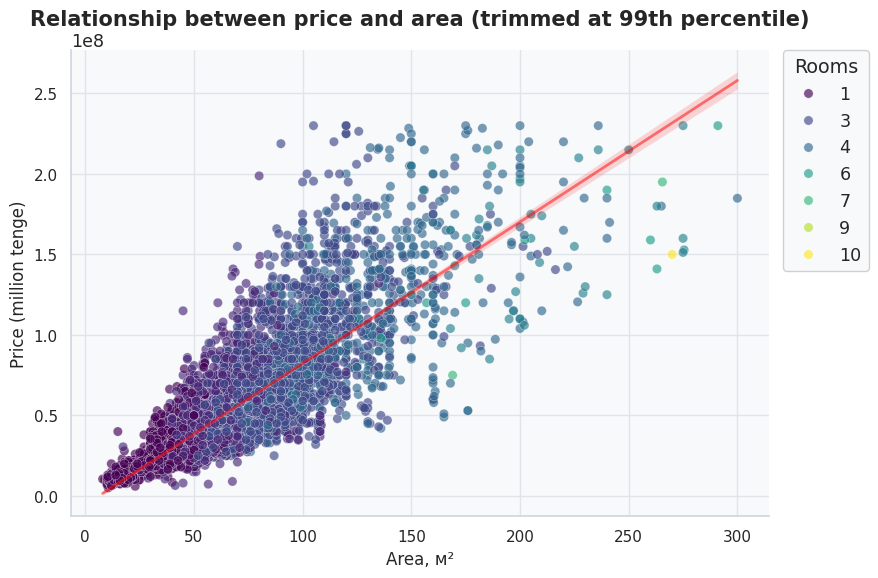

In [ ]:
price_q99 = df["price"].quantile(0.99)
df_scatter = df[df["price"] <= price_q99]

plt.figure(figsize=(9, 6))

ax = sns.scatterplot(
    data=df_scatter,
    x="area_m2",
    y="price",
    hue="rooms",
    palette="viridis",
    alpha=0.65,
    s=45,
    edgecolor="white",
    linewidth=0.3
)

sns.regplot(
    data=df_scatter,
    x="area_m2",
    y="price",
    scatter=False,
    ax=ax,
    color="#FF0000",
    line_kws={"linewidth": 2, "alpha": 0.5}
)

ax.set_title(
    "Relationship between price and area (trimmed at 99th percentile)",
    fontsize=15,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Area, м²", fontsize=12)
ax.set_ylabel("Price (million tenge)", fontsize=12)

legend = ax.legend(
    title="Rooms",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=True
)
legend.get_frame().set_alpha(0.9)

ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()


BoxPLot

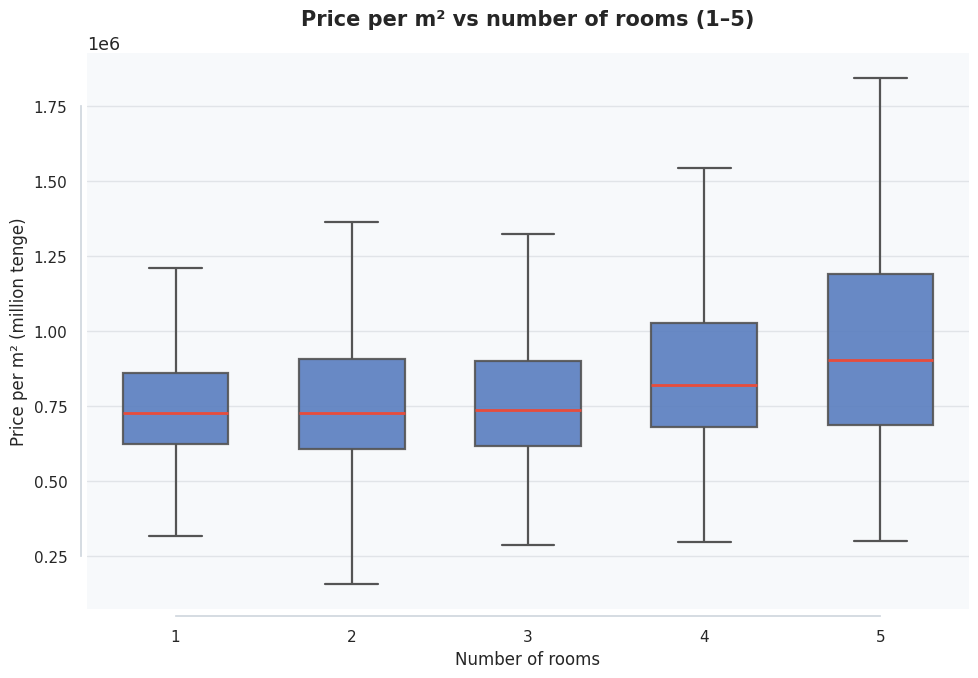

In [ ]:
df_rooms = df[df["rooms"].between(1, 5)]

plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    data=df_rooms,
    x="rooms",
    y="price_per_m2",
    showfliers=False,
    width=0.6,
    linewidth=1.6,
    boxprops=dict(alpha=0.9),
    medianprops=dict(color="#e74c3c", linewidth=2),
)


sns.despine(offset=5, trim=True)

ax.set_title(
    "Price per m² vs number of rooms (1–5)",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Number of rooms", fontsize=12)
ax.set_ylabel("Price per m² (million tenge)", fontsize=12)

ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()



LinePlot

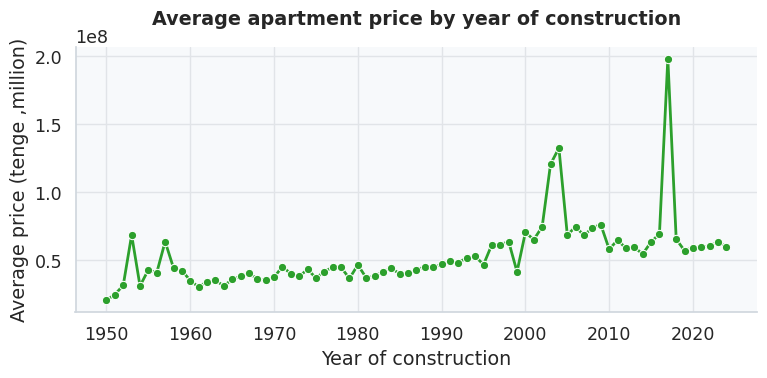

In [ ]:
mean_price_by_year = (
    df[df["year"].between(1950, 2025)]
      .groupby("year")["price"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=mean_price_by_year,
    x="year",
    y="price",
    marker="o",
    color="#2ca02c"
)
plt.title("Average apartment price by year of construction")
plt.xlabel("Year of construction")
plt.ylabel("Average price (tenge ,million)")
plt.tight_layout()
plt.show()


In [ ]:
df["price_per_m2"] = df["price"] / df["area_m2"]

numeric_cols = [
    "price",
    "price_per_m2",
    "area_m2",
    "rooms",
    "year",
    "floor",
    "total_floors"
]

df_numeric = df[numeric_cols].dropna()


In [ ]:
corr =df_numeric.corr()

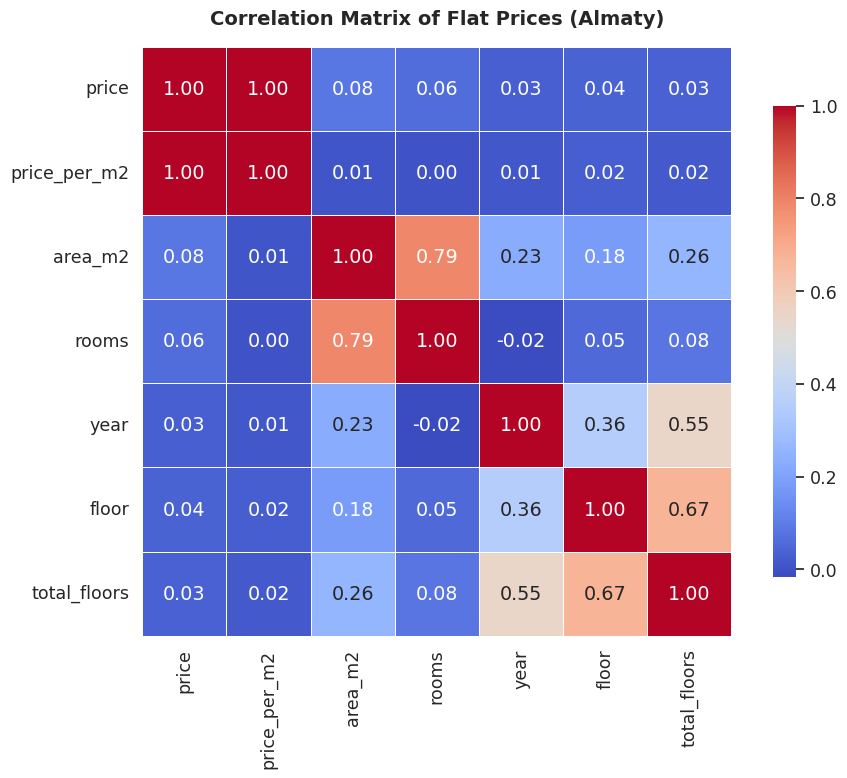

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Flat Prices (Almaty)", fontsize=14)
plt.tight_layout()
plt.show()

# Git

In [ ]:
print('hello team')

hello team
